<a href="https://colab.research.google.com/github/SamiraKheradmand/IASC-ASCE-Transformer-SHM/blob/main/notebooks/02_split_methods/chronological/CNN_highpass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import scipy.io as sio
from scipy.io.matlab._mio5_params import mat_struct
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/ASCE_IASC"

figures		     shm01a.mat  shm04a.mat  shm07a.mat  txt_selected_sensors
processed_zero_mean  shm02a.mat  shm05a.mat  shm08a.mat
Results		     shm03a.mat  shm06a.mat  shm09a.mat


In [ ]:
from pathlib import Path

import numpy as np
import scipy.io as sio


# مسیر فایل‌ها
DATA_DIR = Path("/content/drive/MyDrive/ASCE_IASC")

# فقط 15 سنسور واقعی سازه
CHANNELS = [f"DA{i:02d}" for i in range(1, 16)]

# پیدا کردن فایل‌های 9 حالت سازه
mat_files = sorted(DATA_DIR.glob("shm*.mat"))

print("Folder exists:", DATA_DIR.exists())
print("Number of files:", len(mat_files))
print("Number of channels:", len(CHANNELS))


def load_ambient_file(file_path):
    """
    خواندن یک فایل Ambient از داده‌های IASC-ASCE
    """

    mat = sio.loadmat(file_path,squeeze_me=True,struct_as_record=False)

    dasy = mat["dasy"]
    dasy_dscr = mat["dasy_dscr"]
    fs = float(mat["fsdasy"])

    signals = []
    descriptions = []

    for i, channel in enumerate(CHANNELS, start=1):

        signal = np.asarray(getattr(dasy, channel)).reshape(-1)

        description_name = f"DAdscr{i:02d}"
        description = getattr(dasy_dscr, description_name)

        signals.append(signal)
        descriptions.append(description)

    # شکل خروجی:
    # (تعداد نمونه‌های زمانی، تعداد سنسورها)
    X_raw = np.column_stack(signals)

    return X_raw, fs, descriptions

Folder exists: True
Number of files: 9
Number of channels: 15


In [ ]:
all_cases = {}

for file_path in mat_files:

    case_name = file_path.stem
    case_number = int(case_name[3:5])

    X_raw, fs, descriptions = load_ambient_file(file_path)

    all_cases[case_name] = {
        "X_raw": X_raw,
        "fs": fs,
        "channels": CHANNELS.copy(),
        "descriptions": descriptions,
        "case_number": case_number,
        "label": case_number - 1,
        "file_path": file_path
    }

    print(
        f"{case_name} | "
        f"shape: {X_raw.shape} | "
        f"fs: {fs} Hz | "
        f"label: {case_number - 1}"

    )
print( f"description: {pd.DataFrame(descriptions)}")

shm01a | shape: (60000, 15) | fs: 200.0 Hz | label: 0
shm02a | shape: (60000, 15) | fs: 200.0 Hz | label: 1
shm03a | shape: (60000, 15) | fs: 200.0 Hz | label: 2
shm04a | shape: (60000, 15) | fs: 200.0 Hz | label: 3
shm05a | shape: (60000, 15) | fs: 200.0 Hz | label: 4
shm06a | shape: (45568, 15) | fs: 200.0 Hz | label: 5
shm07a | shape: (180000, 15) | fs: 200.0 Hz | label: 6
shm08a | shape: (180000, 15) | fs: 200.0 Hz | label: 7
shm09a | shape: (180000, 15) | fs: 200.0 Hz | label: 8
description:                                                0
0   Base West side - EPI sensor X direction (N+)
1      Base Center - EPI sensor Y direction (W+)
2   Base East side - EPI sensor X direction (N+)
3    1st Floor - N/S EPI Sensor at West end (N+)
4      1st Floor - E/W FBA Sensor at Center (W+)
5    1st Floor - N/S FBA Sensor at East end (N+)
6    2nd Floor - N/S FBA Sensor at West end (N+)
7      2nd Floor - E/W EPI Sensor at Center (W+)
8    2nd Floor - N/S EPI Sensor at East end (N+)
9    3rd

In [ ]:
print(all_cases["shm01a"]["X_raw"].shape)
print(all_cases["shm01a"]["channels"])


(60000, 15)
['DA01', 'DA02', 'DA03', 'DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']


In [ ]:
RUN_TEST = False

In [ ]:
# ============================================================
# Step 2: Chronological split and Butterworth high-pass filter
# Filter is applied separately to Train, Validation and Test
# ============================================================

import pandas as pd
from scipy.signal import butter, sosfiltfilt


# ----------------------------
# Split settings
# ----------------------------
TRAIN_RATIO = 0.60
VAL_RATIO = 0.20

GAP_SEC = 0
EDGE_SEC = 2


# ----------------------------
# High-pass filter settings
# ----------------------------
CUTOFF = 0.1
ORDER = 2


def highpass_filter(X, fs):

    """
    Apply a Butterworth high-pass filter to all sensor channels.
    X shape:(samples, sensors)
    """

    sos = butter(N=ORDER, Wn=CUTOFF,btype="highpass",fs=fs,output="sos")
    X_filtered = sosfiltfilt(sos,X,axis=0)

    return X_filtered

In [ ]:
train_data = {}
val_data = {}
test_data = {}

split_report = []

for case_name in sorted(all_cases.keys()):

    # Raw data
    X = all_cases[case_name]["X_raw"]
    fs = all_cases[case_name]["fs"]

    n_samples = len(X)

    gap_size = int(GAP_SEC * fs)
    edge_size = int(EDGE_SEC * fs)

    # ----------------------------
    # Chronological split boundaries
    # ----------------------------
    train_end = int(TRAIN_RATIO * n_samples)

    val_start = train_end + gap_size
    val_end = val_start + int(VAL_RATIO * n_samples)

    test_start = val_end + gap_size

    if test_start >= n_samples:
        raise ValueError(f"{case_name}: signal is too short for this gap.")

    # ----------------------------
    # Split raw signal
    # ----------------------------
    X_train_raw = X[:train_end]
    X_val_raw = X[val_start:val_end]
    X_test_raw = X[test_start:]

    # Check split lengths
    if min(len(X_train_raw), len(X_val_raw), len(X_test_raw)) <= 2 * edge_size:
        raise ValueError(f"{case_name}: EDGE_SEC is too large.")

    # ----------------------------
    # Filter each split separately
    # ----------------------------
    X_train_filtered = highpass_filter(X_train_raw, fs)
    X_val_filtered  = highpass_filter(X_val_raw, fs)
    X_test_filtered = highpass_filter(X_test_raw, fs)

    # ----------------------------
    # Remove filter edges
    # ----------------------------
    X_train_filtered = X_train_filtered[edge_size:-edge_size]
    X_val_filtered  = X_val_filtered[edge_size:-edge_size]
    X_test_filtered = X_test_filtered[edge_size:-edge_size]

    # ----------------------------
    # Save filtered data
    # ----------------------------
    train_data[case_name] = X_train_filtered
    val_data[case_name] = X_val_filtered
    test_data[case_name] = X_test_filtered

    split_report.append({
        "case": case_name,
        "total_samples": n_samples,

        "train_samples_filtered": len(X_train_filtered),
        "val_samples_filtered": len(X_val_filtered),
        "test_samples_filtered":len(X_test_filtered),
        "train_duration_sec":len(X_train_filtered) / fs,
        "val_duration_sec":len(X_val_filtered) / fs,
        "test_duration_sec":len(X_test_filtered) / fs
    })


split_report_df = pd.DataFrame(split_report)

display(split_report_df)

,case,total_samples,train_samples_filtered,val_samples_filtered,test_samples_filtered,train_duration_sec,val_duration_sec,test_duration_sec
0,shm01a,60000,35200,11200,11200,176.0,56.000,56.000
1,shm02a,60000,35200,11200,11200,176.0,56.000,56.000
2,shm03a,60000,35200,11200,11200,176.0,56.000,56.000
3,shm04a,60000,35200,11200,11200,176.0,56.000,56.000
4,shm05a,60000,35200,11200,11200,176.0,56.000,56.000
5,shm06a,45568,26540,8313,8315,132.7,41.565,41.575
6,shm07a,180000,107200,35200,35200,536.0,176.000,176.000
7,shm08a,180000,107200,35200,35200,536.0,176.000,176.000
8,shm09a,180000,107200,35200,35200,536.0,176.000,176.000


In [ ]:
for case_name in sorted(train_data.keys()):

    print(f"{case_name} | "
          f"Train: {train_data[case_name].shape} | "
          f"Validation: {val_data[case_name].shape} | "
          f"Test: {test_data[case_name].shape}" )

shm01a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm02a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm03a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm04a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm05a | Train: (35200, 15) | Validation: (11200, 15) | Test: (11200, 15)
shm06a | Train: (26540, 15) | Validation: (8313, 15) | Test: (8315, 15)
shm07a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm08a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)
shm09a | Train: (107200, 15) | Validation: (35200, 15) | Test: (35200, 15)


In [ ]:
filter_check = []

for case_name in sorted(all_cases.keys()):

    raw_train_end = int(TRAIN_RATIO * len(all_cases[case_name]["X_raw"]))
    X_train_raw = all_cases[case_name]["X_raw"][:raw_train_end]
    X_train_filtered = train_data[case_name]

    filter_check.append({
        "case": case_name,
        "mean_abs_raw": np.mean(np.abs(np.mean(X_train_raw, axis=0))),
        "mean_abs_filtered": np.mean(np.abs(np.mean(X_train_filtered,axis=0)))
    })

filter_check_df = pd.DataFrame(filter_check)
display(filter_check_df)

,case,mean_abs_raw,mean_abs_filtered
0,shm01a,0.001260,1.125002e-06
1,shm02a,0.001564,2.848653e-07
2,shm03a,0.000955,3.674356e-07
3,shm04a,0.001096,3.553501e-07
4,shm05a,0.001285,8.238489e-07
5,shm06a,0.001239,2.023264e-06
6,shm07a,0.001139,9.591543e-08
7,shm08a,0.001083,9.232525e-08
8,shm09a,0.001077,1.732560e-07


In [ ]:
# ============================================================
# Step 3: Select sensor channels
# ============================================================

# selected_sensor_indices = [8, 11, 13, 14]  # DA09, DA12, DA14, DA15
# selected_sensor_indices = [0,3]
selected_sensor_indices = [3,4,5,6,7,8,9,10,11,12,13,14]

selected_sensor_names = [CHANNELS[i] for i in selected_sensor_indices]

train_selected = {}
val_selected = {}
test_selected = {}

for case_name in train_data.keys():
    train_selected[case_name] = train_data[case_name][:, selected_sensor_indices]
    val_selected[case_name]   = val_data[case_name][:, selected_sensor_indices]
    test_selected[case_name]  = test_data[case_name][:, selected_sensor_indices]

print("Selected sensors:", selected_sensor_names)

for case_name in sorted(train_selected.keys()):
    print(
        f"Case {case_name}: "
        f"train={train_selected[case_name].shape}, "
        f"val={val_selected[case_name].shape}, "
        f"test={test_selected[case_name].shape}"
    )

Selected sensors: ['DA04', 'DA05', 'DA06', 'DA07', 'DA08', 'DA09', 'DA10', 'DA11', 'DA12', 'DA13', 'DA14', 'DA15']
Case shm01a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm02a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm03a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm04a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm05a: train=(35200, 12), val=(11200, 12), test=(11200, 12)
Case shm06a: train=(26540, 12), val=(8313, 12), test=(8315, 12)
Case shm07a: train=(107200, 12), val=(35200, 12), test=(35200, 12)
Case shm08a: train=(107200, 12), val=(35200, 12), test=(35200, 12)
Case shm09a: train=(107200, 12), val=(35200, 12), test=(35200, 12)


In [ ]:
# ============================================================
# Step 4: Global train-based normalization
# One mean and standard deviation for each selected sensor
# ============================================================

EPS = 1e-8
train_concat = np.concatenate(
    [train_selected[case_name] for case_name in sorted(train_selected.keys())],axis=0)


print("Combined Train shape:", train_concat.shape)
train_mean = train_concat.mean(axis=0,keepdims=True,dtype=np.float64)
train_std = train_concat.std(axis=0,keepdims=True,dtype=np.float64)


# Prevent division by zero
train_std_safe = np.where(train_std < EPS,1.0,train_std)


print("Train mean shape:", train_mean.shape)
print("Train std shape:", train_std_safe.shape)

Combined Train shape: (524140, 12)
Train mean shape: (1, 12)
Train std shape: (1, 12)


In [ ]:
train_norm = {}
val_norm = {}
test_norm = {}


for case_name in sorted(train_selected.keys()):

    train_norm[case_name] = ((train_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    val_norm[case_name]   = ((val_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)
    test_norm[case_name]  = ((test_selected[case_name] - train_mean)/ train_std_safe).astype(np.float32)


print("Normalization completed.")

Normalization completed.


In [ ]:
train_norm_concat = np.concatenate(
    [ train_norm[case_name] for case_name in sorted(train_norm.keys())],axis=0)

normalized_train_mean = train_norm_concat.mean(axis=0)
normalized_train_std = train_norm_concat.std(axis=0)

print("Train mean after normalization:")
print(np.round(normalized_train_mean,5))

print("\nTrain std after normalization:")
print(np.round(normalized_train_std,5))

Train mean after normalization:
[-0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0.  0.]

Train std after normalization:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# ============================================================
# Experiment configuration
# Chronological Split + High-pass + Raw 1D-CNN
# ============================================================

EXPERIMENT_NAME = "Chronological_Highpass_RawCNN_12Sensors"
MODEL_NAME = "Raw 1D-CNN"

BATCH_SIZE = 64

CUTOFF = 0.10
FILTER_ORDER = 2


RUN_TEST = False

In [ ]:
# ============================================================
# Step 5: Create non-overlapping time windows
# ============================================================

WINDOW_SIZE = 512
STEP_SIZE = 512

FS_DASY = 200

print("Window size:", WINDOW_SIZE, "samples")
print("Window duration:", WINDOW_SIZE / FS_DASY, "seconds")
print("Step size:", STEP_SIZE, "samples")
print("Step duration:", STEP_SIZE / FS_DASY, "seconds")

Window size: 512 samples
Window duration: 2.56 seconds
Step size: 512 samples
Step duration: 2.56 seconds


In [ ]:
def make_windows(split_data):
    """
    Convert continuous signals of each scenario into fixed-length windows.
    Input:
        split_data[case_name]
        shape = (samples, selected_sensors)

    Output:
        X_windows shape = (number_of_windows, window_size, selected_sensors)
        y_labels shape = (number_of_windows,)
    """

    all_windows = []
    all_labels = []
    meta_rows = []

    for case_name in sorted(split_data.keys()):

        X = split_data[case_name]

        n_samples = len(X)

        # shm01a -> scenario 1 -> label 0
        scenario_number = int(case_name[3:5])
        label = scenario_number - 1

        window_number = 0

        for start in range(0, n_samples - WINDOW_SIZE + 1,STEP_SIZE):

            end = start + WINDOW_SIZE

            window = X[start:end, :]

            all_windows.append(window)
            all_labels.append(label)

            meta_rows.append({
                "case": case_name,
                "scenario": scenario_number,
                "label": label,
                "window": window_number,
                "start_sample": start,
                "end_sample": end
            })

            window_number += 1

    if len(all_windows) == 0:
        raise ValueError("No windows were created.")

    X_windows = np.stack(all_windows,axis=0).astype(np.float32)

    y_labels = np.array(all_labels,dtype=np.int64)

    meta_df = pd.DataFrame(meta_rows)

    return X_windows, y_labels, meta_df

In [ ]:
X_train, y_train, train_meta_df = make_windows(train_norm)

X_val, y_val, val_meta_df = make_windows(val_norm)

X_test, y_test, test_meta_df = make_windows(test_norm)

In [ ]:
print("Window shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nLabel shapes:")
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

Window shapes:
X_train: (1018, 512, 12)
X_val:   (325, 512, 12)
X_test:  (325, 512, 12)

Label shapes:
y_train: (1018,)
y_val:   (325,)
y_test:  (325,)


In [ ]:
print("\nTrain class counts:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation class counts:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())


Train class counts:
0     68
1     68
2     68
3     68
4     68
5     51
6    209
7    209
8    209
Name: count, dtype: int64

Validation class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64

Test class counts:
0    21
1    21
2    21
3    21
4    21
5    16
6    68
7    68
8    68
Name: count, dtype: int64


In [ ]:
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# بررسی داده‌ها قبل از Tensor
# ----------------------------
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:  ", y_val.shape)
print("y_test shape: ", y_test.shape)


# تعداد داده و برچسب باید برابر باشد
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

# بررسی NaN و Inf
assert np.isfinite(X_train).all(), "X_train contains NaN or Inf."
assert np.isfinite(X_val).all(), "X_val contains NaN or Inf."
assert np.isfinite(X_test).all(), "X_test contains NaN or Inf."

print("Data check completed.")

X_train shape: (1018, 512, 12)
X_val shape:   (325, 512, 12)
X_test shape:  (325, 512, 12)
y_train shape: (1018,)
y_val shape:   (325,)
y_test shape:  (325,)
Data check completed.


In [ ]:
# ============================================================
# Step 6: Convert arrays to PyTorch tensors
# ============================================================

import random
import numpy as np
import torch

from torch.utils.data import TensorDataset, DataLoader


# ----------------------------
# Reproducibility
# ----------------------------
SEED = 2026

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Warn if a nondeterministic operation is used
    torch.use_deterministic_algorithms(True,warn_only=True)

set_seed(SEED)
print("Training seed:", SEED)

# Inputs must be float32
X_train_tensor = torch.from_numpy(X_train.astype(np.float32, copy=False))
X_val_tensor = torch.from_numpy(X_val.astype(np.float32, copy=False))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32, copy=False))


# Labels for CrossEntropyLoss must be int64
y_train_tensor = torch.from_numpy(y_train.astype(np.int64, copy=False))
y_val_tensor = torch.from_numpy(y_val.astype(np.int64, copy=False))
y_test_tensor = torch.from_numpy(y_test.astype(np.int64, copy=False))


print("\nTensor shapes:")
print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)

print("X_val_tensor:", X_val_tensor.shape)
print("y_val_tensor:", y_val_tensor.shape)

print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

Training seed: 2026

Tensor shapes:
X_train_tensor: torch.Size([1018, 512, 12])
y_train_tensor: torch.Size([1018])
X_val_tensor: torch.Size([325, 512, 12])
y_val_tensor: torch.Size([325])
X_test_tensor: torch.Size([325, 512, 12])
y_test_tensor: torch.Size([325])


In [ ]:
# ============================================================
# Create Dataset and DataLoader
# ============================================================

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,y_test_tensor)

BATCH_SIZE = 64

# برای تکرارپذیری Shuffle داده‌های Train
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)


train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True,generator=loader_generator)
val_loader   = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

In [ ]:
print("Number of train samples:", len(train_dataset))
print("Number of val samples:  ", len(val_dataset))
print("Number of test samples: ", len(test_dataset))

print("\nNumber of train batches:", len(train_loader))
print("Number of val batches:  ", len(val_loader))
print("Number of test batches: ", len(test_loader))


X_batch, y_batch = next(iter(train_loader))

print("\nOne train batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First 10 labels:", y_batch[:10])

Number of train samples: 1018
Number of val samples:   325
Number of test samples:  325

Number of train batches: 16
Number of val batches:   6
Number of test batches:  6

One train batch:
X_batch shape: torch.Size([64, 512, 12])
y_batch shape: torch.Size([64])
First 10 labels: tensor([7, 8, 6, 4, 7, 7, 8, 7, 1, 8])


In [ ]:
# ============================================================
# Step: Define Raw 1D-CNN
# Input shape: (batch, time, channels)
# ============================================================

import torch
import torch.nn as nn


class RawCNN1D(nn.Module):

    def __init__(self,input_channels,num_classes,dropout=0.10):
        super().__init__()

        # First convolution block
        self.conv_block1 = nn.Sequential(
            nn.Conv1d(
                in_channels=input_channels,
                out_channels=32,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Second convolution block
        self.conv_block2 = nn.Sequential(
            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        # Third convolution block
        self.conv_block3 = nn.Sequential(
            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        # Convert temporal features to one feature vector
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )


    def forward(self, x):

        # Input:
        # x shape = (batch, time, channels)

        # Conv1d expects:
        # (batch, channels, time)
        x = x.transpose(1, 2)

        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = self.global_pool(x)

        # Shape:
        # (batch, 128, 1) -> (batch, 128)
        x = x.squeeze(-1)

        logits = self.classifier(x)

        return logits

In [ ]:
# ============================================================
# Create a fresh CNN model
# ============================================================

set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

INPUT_CHANNELS = X_train_tensor.shape[2]
NUM_CLASSES = len(torch.unique(y_train_tensor))

model = RawCNN1D(
    input_channels=INPUT_CHANNELS,
    num_classes=NUM_CLASSES,
    dropout=0.10
).to(device)

print(model)
print("Device:", device)
print("Input channels:", INPUT_CHANNELS)
print("Number of classes:", NUM_CLASSES)

RawCNN1D(
  (conv_block1): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=128, out_features=9, bias=True)
  )
)
Device: cpu
Inpu

In [ ]:
# ============================================================
# Check input and output shapes
# ============================================================

X_batch, y_batch = next(iter(train_loader))
print("Input batch shape:", X_batch.shape)

model.eval()

with torch.no_grad():
    logits = model(X_batch.to(device))

print("Output logits shape:", logits.shape)

Input batch shape: torch.Size([64, 512, 12])
Output logits shape: torch.Size([64, 9])


In [ ]:

# ----------------------------
# Count trainable parameters
# ----------------------------
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


Trainable parameters: 39,337


In [ ]:
# ============================================================
# Step 8: Loss function and optimizer
# ============================================================

class_counts = torch.bincount(y_train_tensor, minlength=NUM_CLASSES).float()
if torch.any(class_counts == 0):
    raise ValueError("At least one class has no training samples.")

class_weights = (len(y_train_tensor) / (NUM_CLASSES * class_counts))
class_weights = class_weights.to(device)

print("Class counts and weights:")

for class_id in range(NUM_CLASSES):

    print(
        f"Scenario {class_id + 1} | "
        f"count: {int(class_counts[class_id])} | "
        f"weight: {class_weights[class_id].item():.4f}"
    )

Class counts and weights:
Scenario 1 | count: 68 | weight: 1.6634
Scenario 2 | count: 68 | weight: 1.6634
Scenario 3 | count: 68 | weight: 1.6634
Scenario 4 | count: 68 | weight: 1.6634
Scenario 5 | count: 68 | weight: 1.6634
Scenario 6 | count: 51 | weight: 2.2179
Scenario 7 | count: 209 | weight: 0.5412
Scenario 8 | count: 209 | weight: 0.5412
Scenario 9 | count: 209 | weight: 0.5412


In [ ]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", LEARNING_RATE)

Loss function: CrossEntropyLoss()
Optimizer: AdamW
Learning rate: 0.001


In [ ]:
# Reset early stopping
best_val_macro_f1 = -1.0
best_val_loss = float("inf")

best_epoch = 0
best_model_state = None

patience_counter = 0
print("New experiment started")
print("Seed:", SEED)
print("Learning rate:", LEARNING_RATE)

New experiment started
Seed: 2026
Learning rate: 0.001


In [ ]:
CHECKPOINT_PATH = (f"best_raw_cnn_seed_{SEED}_lr_{LEARNING_RATE}.pt")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import copy
import torch

NUM_EPOCHS = 100
PATIENCE = 20
GRAD_CLIP = 1.0
MIN_DELTA = 1e-4

LABELS_ORDER = np.arange(NUM_CLASSES)

transformer_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": [],
}

best_val_macro_f1 = -1.0
best_epoch = 0  # Initializing best_epoch to 0
best_model_state = None
epochs_without_improvement = 0


def run_one_epoch_transformer(model, data_loader, criterion, optimizer=None, device="cpu"):
    """
    If optimizer is given: training mode
    If optimizer is None: evaluation mode
    """

    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for xb, yb in data_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_training:
                loss.backward()

                # Gradient clipping helps Transformer training stability
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)

                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_labels.append(yb.detach().cpu())

    avg_loss = total_loss / len(data_loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return avg_loss, acc, macro_f1


for epoch in range(1, NUM_EPOCHS + 1):

    train_loss, train_acc, train_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = run_one_epoch_transformer(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        optimizer=None,
        device=device
    )

    transformer_history["epoch"].append(epoch)
    transformer_history["train_loss"].append(train_loss)
    transformer_history["train_acc"].append(train_acc)
    transformer_history["train_macro_f1"].append(train_macro_f1)
    transformer_history["val_loss"].append(val_loss)
    transformer_history["val_acc"].append(val_acc)
    transformer_history["val_macro_f1"].append(val_macro_f1)

    # Save best model based on validation Macro-F1
    if val_macro_f1 > best_val_macro_f1 + MIN_DELTA:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch # Assign epoch here
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train Macro-F1: {train_macro_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

assert best_model_state is not None, "No best model was saved."

# Load best validation model
model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best validation Macro-F1:", best_val_macro_f1)


Epoch 001 | Train Loss: 1.4533 | Train Acc: 0.6257 | Train Macro-F1: 0.6221 | Val Loss: 1.4790 | Val Acc: 0.7231 | Val Macro-F1: 0.6794
Epoch 005 | Train Loss: 0.1208 | Train Acc: 0.9813 | Train Macro-F1: 0.9893 | Val Loss: 0.1279 | Val Acc: 0.9877 | Val Macro-F1: 0.9861
Epoch 010 | Train Loss: 0.0255 | Train Acc: 0.9980 | Train Macro-F1: 0.9989 | Val Loss: 0.0236 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Epoch 015 | Train Loss: 0.0104 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 0.0119 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Epoch 020 | Train Loss: 0.0060 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 0.0070 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Epoch 025 | Train Loss: 0.0038 | Train Acc: 1.0000 | Train Macro-F1: 1.0000 | Val Loss: 0.0060 | Val Acc: 1.0000 | Val Macro-F1: 1.0000

Early stopping at epoch 28.

Training finished.
Best validation Macro-F1: 1.0


In [ ]:
if best_model_state is None:
    raise RuntimeError("No best model was saved.")

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print("Best epoch:",best_epoch)
print("Best validation Macro-F1:",best_val_macro_f1)


Training finished.
Best epoch: 8
Best validation Macro-F1: 1.0


In [ ]:
# # ============================================================
# # Step 10: Final evaluation
# # ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import torch


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

def predict_with_model_transformer(model, data_loader, device="cpu"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return all_labels, all_preds


def final_evaluate_transformer(model, data_loader, split_name, device="cpu"):
    y_true, y_pred = predict_with_model_transformer(
        model=model,
        data_loader=data_loader,
        device=device
    )

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {split_name} =====")
    print(f"Accuracy:    {acc:.4f}")
    print(f"Macro-F1:    {macro_f1:.4f}")
    print(f"Weighted-F1: {weighted_f1:.4f}")

    labels_order = np.arange(NUM_CLASSES)
    target_names = [f"Scenario {i+1}" for i in labels_order]

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            labels=labels_order,
            digits=4,
            zero_division=0
        )
    )

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred
    }


model.eval()

transformer_train_results = final_evaluate_transformer(
    model, train_eval_loader, "TRAIN", device=device
)

transformer_val_results = final_evaluate_transformer(
    model, val_loader, "VALIDATION", device=device
)

transformer_test_results = final_evaluate_transformer(
    model, test_loader, "TEST", device=device
)

transformer_summary_results = pd.DataFrame([
    {
        "model": "Transformer",
        "split": transformer_train_results["split"],
        "accuracy": transformer_train_results["accuracy"],
        "macro_f1": transformer_train_results["macro_f1"],
        "weighted_f1": transformer_train_results["weighted_f1"],
    },
    {
        "model": "Transformer",
        "split": transformer_val_results["split"],
        "accuracy": transformer_val_results["accuracy"],
        "macro_f1": transformer_val_results["macro_f1"],
        "weighted_f1": transformer_val_results["weighted_f1"],
    },
    {
        "model": "Transformer",
        "split": transformer_test_results["split"],
        "accuracy": transformer_test_results["accuracy"],
        "macro_f1": transformer_test_results["macro_f1"],
        "weighted_f1": transformer_test_results["weighted_f1"],
    }
])

display(transformer_summary_results)


===== TRAIN =====
Accuracy:    0.9961
Macro-F1:    0.9979
Weighted-F1: 0.9961

Classification Report:
              precision    recall  f1-score   support

  Scenario 1     1.0000    1.0000    1.0000        68
  Scenario 2     1.0000    1.0000    1.0000        68
  Scenario 3     1.0000    1.0000    1.0000        68
  Scenario 4     1.0000    1.0000    1.0000        68
  Scenario 5     1.0000    1.0000    1.0000        68
  Scenario 6     1.0000    1.0000    1.0000        51
  Scenario 7     0.9905    1.0000    0.9952       209
  Scenario 8     0.9905    1.0000    0.9952       209
  Scenario 9     1.0000    0.9809    0.9903       209

    accuracy                         0.9961      1018
   macro avg     0.9979    0.9979    0.9979      1018
weighted avg     0.9961    0.9961    0.9961      1018


===== VALIDATION =====
Accuracy:    1.0000
Macro-F1:    1.0000
Weighted-F1: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Scenario 1     1.0000    1.

,model,split,accuracy,macro_f1,weighted_f1
0,Transformer,TRAIN,0.996071,0.997868,0.996061
1,Transformer,VALIDATION,1.000000,1.000000,1.000000
2,Transformer,TEST,0.972308,0.954444,0.971381


In [ ]:
train_results = final_evaluate_transformer(
    model,
    train_loader,
    "TRAIN",
    device
)

val_results = final_evaluate_transformer(
    model,
    val_loader,
    "VALIDATION",
    device
)


===== TRAIN =====
Accuracy:    0.9961
Macro-F1:    0.9979
Weighted-F1: 0.9961

Classification Report:
              precision    recall  f1-score   support

  Scenario 1     1.0000    1.0000    1.0000        68
  Scenario 2     1.0000    1.0000    1.0000        68
  Scenario 3     1.0000    1.0000    1.0000        68
  Scenario 4     1.0000    1.0000    1.0000        68
  Scenario 5     1.0000    1.0000    1.0000        68
  Scenario 6     1.0000    1.0000    1.0000        51
  Scenario 7     0.9905    1.0000    0.9952       209
  Scenario 8     0.9905    1.0000    0.9952       209
  Scenario 9     1.0000    0.9809    0.9903       209

    accuracy                         0.9961      1018
   macro avg     0.9979    0.9979    0.9979      1018
weighted avg     0.9961    0.9961    0.9961      1018


===== VALIDATION =====
Accuracy:    1.0000
Macro-F1:    1.0000
Weighted-F1: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Scenario 1     1.0000    1.

In [ ]:
RUN_TEST = False # Define RUN_TEST as a boolean variable

if RUN_TEST:

    test_results = final_evaluate_transformer( # Use final_evaluate_transformer
        model,
        test_loader,
        "TEST", # Specify split_name as 'TEST'
        device
    )

    # Extract values from the dictionary returned by final_evaluate_transformer
    # Note: final_evaluate_transformer does not return test_loss directly.
    test_acc = test_results["accuracy"]
    test_f1 = test_results["macro_f1"]
    y_test_true = test_results["y_true"]
    y_test_pred = test_results["y_pred"]

    print("Final Test Macro-F1:", test_f1)

else:

    print(
        "Test evaluation skipped. "
        "The model is still in the tuning stage."
    )

Test evaluation skipped. The model is still in the tuning stage.


In [ ]:
if RUN_TEST:

    print(
        classification_report(
            y_test_true,
            y_test_pred,
            digits=4
        )
    )

    cm = confusion_matrix(
        y_test_true,
        y_test_pred
    )

    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title("Test Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    plt.colorbar()
    plt.show()

In [ ]:
transformer_summary_results = pd.DataFrame([
    {
        "model":"Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + "
            "Train-based normalization",
        "selected_sensors": len(selected_sensor_names),
        "split": transformer_train_results["split"],
        "accuracy":transformer_train_results["accuracy"],
        "macro_f1": transformer_train_results["macro_f1"],
        "weighted_f1": transformer_train_results["weighted_f1"]
    },

    {
        "model":"raw Transformer",
        "preprocessing":
            "Butterworth high-pass + "
            "Train-based normalization",

        "selected_sensors":len(selected_sensor_names),
        "split":transformer_val_results["split"],
        "accuracy":transformer_val_results["accuracy"],
        "macro_f1":transformer_val_results["macro_f1"],
        "weighted_f1":transformer_val_results["weighted_f1"]
    },

    {
        "model":
            "Raw Transformer",
        "preprocessing":
            "Butterworth high-pass + "
            "Train-based normalization",
        "selected_sensors":len(selected_sensor_names),
        "split":transformer_test_results["split"],
        "accuracy":transformer_test_results["accuracy"],
        "macro_f1":transformer_test_results["macro_f1"],
        "weighted_f1":transformer_test_results["weighted_f1"]
    }
])


display(transformer_summary_results)

,model,preprocessing,selected_sensors,split,accuracy,macro_f1,weighted_f1
0,Raw Transformer,Butterworth high-pass + Train-based normalization,12,TRAIN,0.996071,0.997868,0.996061
1,raw Transformer,Butterworth high-pass + Train-based normalization,12,VALIDATION,1.000000,1.000000,1.000000
2,Raw Transformer,Butterworth high-pass + Train-based normalization,12,TEST,0.972308,0.954444,0.971381


In [ ]:
# Chronological + High-pass + Raw Transformer + 12 sensors

# Test Accuracy    = 0.9892 ± 0.0018
# Test Macro-F1    = 0.9930 ± 0.0021
# Test Weighted-F1 = 0.9893 ± 0.0018

In [ ]:
# Seed = 2026
# Test Macro-F1 = 0.995120

<Figure size 800x700 with 0 Axes>

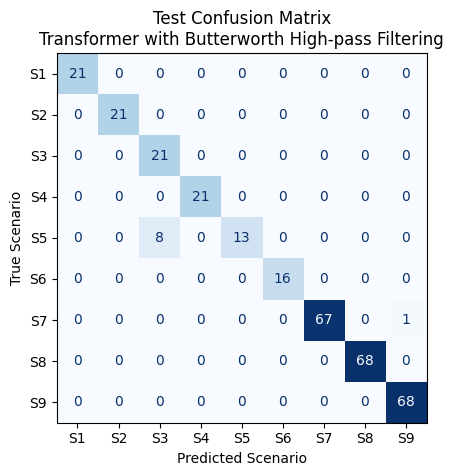

Transformer test confusion matrix:
[[21  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0]
 [ 0  0 21  0  0  0  0  0  0]
 [ 0  0  0 21  0  0  0  0  0]
 [ 0  0  8  0 13  0  0  0  0]
 [ 0  0  0  0  0 16  0  0  0]
 [ 0  0  0  0  0  0 67  0  1]
 [ 0  0  0  0  0  0  0 68  0]
 [ 0  0  0  0  0  0  0  0 68]]


In [ ]:
# ============================================================
# Step 11: Test confusion matrix
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True and predicted labels from Transformer test results
y_true_test = transformer_test_results["y_true"]
y_pred_test = transformer_test_results["y_pred"]

labels_order = np.arange(NUM_CLASSES)
display_labels = [f"S{i+1}" for i in labels_order]

cm_transformer_test = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=labels_order
)

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_transformer_test,
    display_labels=display_labels
)

disp.plot(
    values_format="d",
    cmap="Blues",
    colorbar=False
)

plt.title("Test Confusion Matrix\n"
    "Transformer with Butterworth High-pass Filtering")
plt.xlabel("Predicted Scenario")
plt.ylabel("True Scenario")
plt.grid(False)
plt.show()

print("Transformer test confusion matrix:")
print(cm_transformer_test)

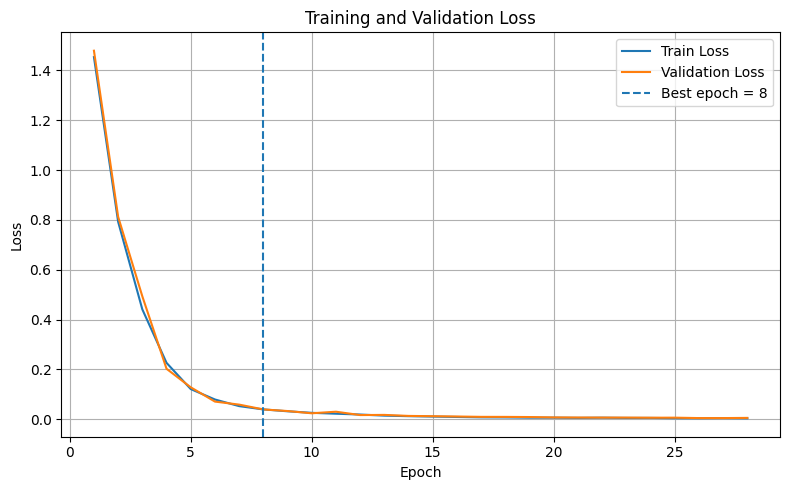

In [ ]:
# ============================================================
# Step 12: Training curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_loss"],
    label="Train Loss"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

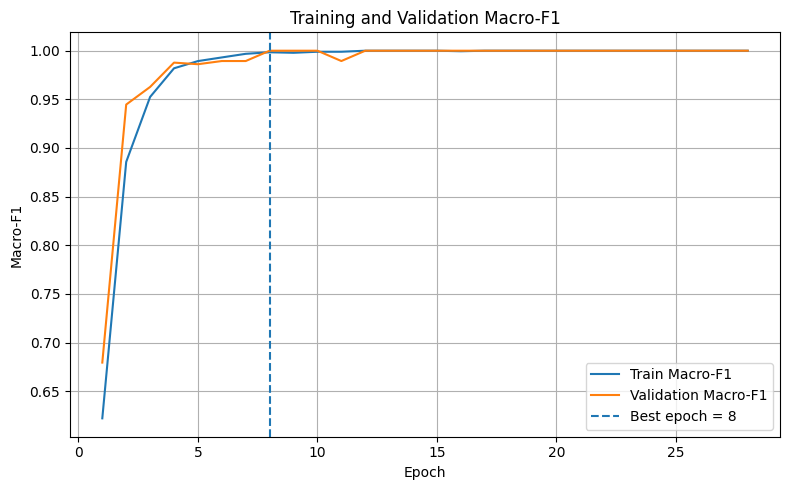

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    transformer_history["epoch"],
    transformer_history["train_macro_f1"],
    label="Train Macro-F1"
)

plt.plot(
    transformer_history["epoch"],
    transformer_history["val_macro_f1"],
    label="Validation Macro-F1"
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Training and Validation Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()